In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-09-28T17:51:31.402316+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
requests  : 2.34.2
numpy     : 2.1.2
marimo    : 0.23.2
pandas    : 2.2.3
teeplot   : 1.4.2
matplotlib: 3.10.7

```

## Data

Render a reproduction of Figure 3 from Koopman & Eisenberg,
"An allele-based evolution model of the population spread of
SARS-CoV-2" (medRxiv, <https://doi.org/10.1101/2025.09.15.25335781>).
That figure follows a fully susceptible population through an
initial outbreak of a 2-allele strain, its immune-driven mutational
replacement, and the ensuing damped oscillations in strain
prevalence.
The underlying Madonna ODE-model trajectory is hosted on OSF as
`Fig3.csv` (<https://osf.io/jy59v>) and downloaded below with no
caching-key CLI arguments (this is a visualization notebook).
Columns are keyed `TIME` plus one variable per 2-allele strain
(named by the pair of mutated sites, e.g. `02`, `03`, `12`, `13`):
a `J**` column gives that strain's prevalence, and a `SuscToI**`
column gives the population's fraction still susceptible to
(re)infection by that strain.
In the reference dynamic, strain `02` seeds the initial wave.
Immunity to it wanes unevenly across its two alleles, permitting
mutations to intermediate strains `03` and `12` at vanishingly low
prevalence.
Both intermediates mutate onward to strain `13`, which faces little
standing immunity and comes to dominate later waves.

In [ ]:
def fetch_osf(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=120)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_csv(cache_path)

In [ ]:
fig3_df = fetch_osf("jy59v")
fig3_df.columns = [col.replace(":1", "") for col in fig3_df.columns]
print(f"loaded Fig3 dataframe: {fig3_df.shape}")
print(fig3_df.head().to_string(index=False))

downloading https://osf.io/jy59v/download -> /tmp/jy59v
size: 266925 bytes
loaded Fig3 dataframe: (3001, 9)
 TIME  J13      J02  J03  J12  SuscToI02  SuscToI03  SuscToI12  SuscToI13
    0  0.0 0.000010  0.0  0.0   0.999990   0.999990   0.999990   0.999990
    1  0.0 0.000012  0.0  0.0   0.999987   0.999987   0.999987   0.999988
    2  0.0 0.000015  0.0  0.0   0.999983   0.999983   0.999983   0.999985
    3  0.0 0.000018  0.0  0.0   0.999978   0.999979   0.999979   0.999982
    4  0.0 0.000022  0.0  0.0   0.999972   0.999973   0.999973   0.999978


## Strain Dynamics Render

Two panels stacked vertically, sharing a strain color hue.
Top: per-strain prevalence over time (zero-prevalence stretches,
i.e. before a strain has yet mutated into existence, are left as
gaps), rendered three times with a different y-axis scale each
time (symlog, log, and linear) to show the damped oscillations at
both the strain-replacement scale and the many-orders-of-magnitude
scale of a strain's initial emergence.
Bottom: per-strain fraction of the population susceptible to
reinfection, always on a linear scale.

In [ ]:
long_df = fig3_df.melt(
    id_vars="TIME",
    var_name="variable",
    value_name="value",
)
long_df["strain"] = long_df["variable"].str.slice(-2)
is_susceptibility = long_df["variable"].str.startswith("Susc")
long_df["quantity"] = is_susceptibility.map(
    {True: "susceptibility", False: "prevalence"},
)
zeroed_prevalence = (long_df["quantity"] == "prevalence") & (
    long_df["value"] == 0
)
long_df.loc[zeroed_prevalence, "value"] = float("nan")

teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=symlog+ext=.pdf
teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=symlog+ext=.png


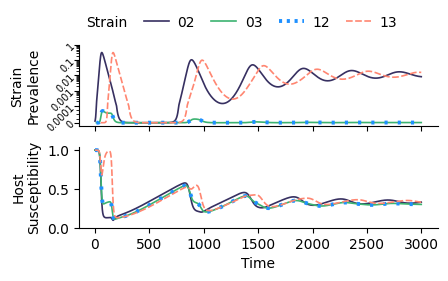

teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=log+ext=.pdf
teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=log+ext=.png


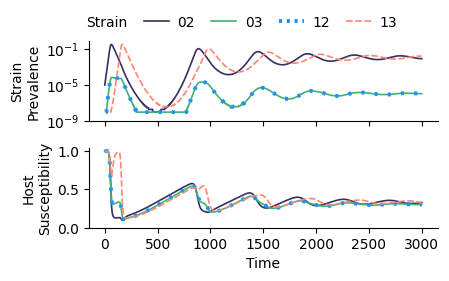

teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=linear+ext=.pdf
teeplots/2026-09-26-figrender/a=fig3-strain-dynamics+hue=strain+kind=line+row=quantity+style=strain+viz=relplot+x=time+y=value+yscale=linear+ext=.png


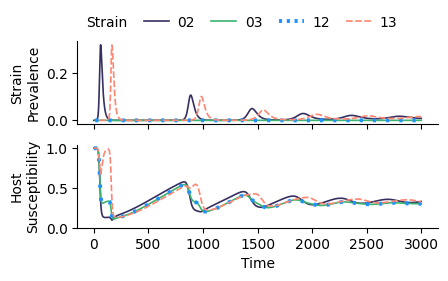

In [ ]:
_strain_order = ["02", "03", "12", "13"]
# Named colors ordered by mutational distance from founder strain
# 02: wt is a subdued dark blue-purple, the two single-mutant
# intermediates (03, 12) are medium-intensity green/blue, and
# double-mutant 13 is the most intense (a warm coral-orange), all
# checked for readable contrast against a white background.
_palette = {
    "02": "#373061",
    "03": "#3cb371",
    "12": "#1e90ff",
    "13": "#ff8671",
}
_dashes = {
    "02": "",
    "03": "",
    "12": (0.8, 2.6),
    "13": (4, 1.5),
}
_dotted_rgb = mcolors.to_rgb(_palette["12"])

def _fmt(y, _):
    if y == 0:
        return "0"
    return f"{y:.10f}".rstrip("0").rstrip(".")

for _yscale in ["symlog", "log", "linear"]:
    with tp.teed(
        sns.relplot,
        data=long_df,
        x="TIME",
        y="value",
        hue="strain",
        hue_order=_strain_order,
        style="strain",
        style_order=_strain_order,
        dashes=_dashes,
        palette=_palette,
        linewidth=1.2,
        row="quantity",
        row_order=["prevalence", "susceptibility"],
        kind="line",
        facet_kws=dict(sharey=False),
        teeplot_outattrs={
            "a": "fig3-strain-dynamics",
            "yscale": _yscale,
        },
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as g:
        g.axes_dict["prevalence"].set_ylabel("Strain\nPrevalence")
        g.axes_dict["susceptibility"].set_ylabel("Host\nSusceptibility")
        g.axes_dict["susceptibility"].set_xlabel("Time")
        g.axes_dict["susceptibility"].set_yticks([0.0, 0.5, 1.0])
        g.axes_dict["susceptibility"].set_ylim(bottom=0.0)
        g.set_titles("")

        if _yscale == "symlog":
            # Linear near zero (below 1e-4) so the exact-zero gaps
            # stay well-defined, log above it; tick decades are
            # spelled out explicitly since the default symlog
            # locator doesn't reach this far down on its own.
            g.axes_dict["prevalence"].set_yscale("symlog", linthresh=1e-4)
            # Small negative bottom so the y=0 line isn't flush
            # against the axis edge, without a tick below zero.
            g.axes_dict["prevalence"].set_ylim(bottom=-2e-5, top=1)
            g.axes_dict["prevalence"].set_yticks(
                [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]
            )
            g.axes_dict["prevalence"].yaxis.set_major_formatter(
                mticker.FuncFormatter(_fmt)
            )
            # Minor ticks double as a visual cue for where the
            # scale is log (uneven, sub-decade spacing) versus
            # linear (evenly spaced) near zero.
            _log_minors = mticker.SymmetricalLogLocator(
                base=10,
                linthresh=1e-4,
                subs=np.arange(2, 10),
                transform=g.axes_dict["prevalence"].yaxis.get_transform(),
            ).tick_values(1e-4, 1)
            _linear_minors = np.linspace(0, 1e-4, 5)[1:-1]
            g.axes_dict["prevalence"].yaxis.set_minor_locator(
                mticker.FixedLocator([*_linear_minors, *_log_minors])
            )
            g.axes_dict["prevalence"].tick_params(
                axis="y", which="major", pad=-2, labelsize=7
            )
            g.axes_dict["prevalence"].tick_params(
                axis="y", which="minor", length=2
            )
            # Angled labels take less horizontal room, so they can
            # sit closer to the axis.
            for _tick in g.axes_dict["prevalence"].get_yticklabels():
                _tick.set_rotation(45)
                _tick.set_ha("right")
        elif _yscale == "log":
            g.axes_dict["prevalence"].set_yscale("log")
            g.axes_dict["prevalence"].set_ylim(bottom=1e-9)

        # Widen 12's dotted line beyond the shared base linewidth
        # so its sparser dots stay legible.
        for _ax in g.axes.flat:
            for _line in _ax.lines:
                if mcolors.to_rgb(_line.get_color()) == _dotted_rgb:
                    _line.set_linewidth(2.8)

        g.figure.set_size_inches(4.6, 2.6)
        g.figure.tight_layout()

        # Fold the "strain" title into the legend's single row as
        # a label-only dummy entry, rather than a separate title
        # line.
        _handles = g.legend.legend_handles
        _labels = [_t.get_text() for _t in g.legend.get_texts()]
        for _handle, _label in zip(_handles, _labels):
            if _label == "12":
                # Denser dashes than the plotted line so the short
                # legend key still reads clearly as dotted.
                _handle.set_linewidth(2.8)
                _handle.set_dashes([0.8, 1.2])
        _dummy = mlines.Line2D([], [], linestyle="none", label="Strain")
        g.legend.remove()
        g.figure.legend(
            handles=[_dummy, *_handles],
            labels=["Strain", *_labels],
            loc="upper center",
            bbox_to_anchor=(0.5, 1.09),
            ncol=len(_labels) + 1,
            frameon=False,
            handlelength=1.8,
            handletextpad=0.6,
            columnspacing=1.2,
        )